# Финальный проект — Блок 3 (Python)

**Данные:** `данные/data_блок3_продажи.csv` — это тот самый `data.csv` из задания
(колонки `Дата`, `Склад`, `Контрагент`, `Номенклатура`, `Количество`).

**Погода:** исходная выгрузка с [rp5.ru — Архив погоды в Астане](https://rp5.ru/Архив_погоды_в_Астане)
лежит в `данные/rp5_астана_2018_исходные.csv`; преобразование к виду «Дата + средняя температура за день»
сделано прямо в блокноте (вопрос 10).

Ниже каждый вопрос задания вынесен в отдельный заголовок, под ним — код, под кодом — вывод и разбор.
Все пояснения вынесены в markdown, код оставлен чистым.

## Подготовка: импорт библиотек и настройка вывода

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.1


---
## Вопрос 1. Прочитать данные в переменную `df` и вывести несколько первых строк

Читаем CSV через `pd.read_csv`. Путь относительный (`данные/...`), поэтому блокнот запускается
прямо из папки урока.

In [2]:
df = pd.read_csv("данные/data_блок3_продажи.csv")

print("Размер таблицы:", df.shape[0], "строк,", df.shape[1], "столбцов")
df.head(10)

Размер таблицы: 301355 строк, 5 столбцов


,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2
5,2018-01-04,1,address_0,product_5,2
6,2018-01-04,1,address_0,product_6,0
7,2018-01-04,1,address_0,product_7,1
8,2018-01-04,1,address_0,product_8,1
9,2018-01-04,1,address_0,product_9,0


**Что получилось:** 301 355 строк и 5 столбцов. Одна строка = одна продажа: дата, номер склада,
контрагент (адрес доставки), номенклатура (товар) и количество штук.

---
## Вопрос 2. Проверить формат столбцов

Смотрим `dtypes`, `info()` и заодно проверяем пропуски и уникальные значения ключевых полей.

In [3]:
print("Типы столбцов:")
print(df.dtypes)
print()
print("Пропуски по столбцам:")
print(df.isna().sum())
print()
print("Уникальных значений: Склад =", df["Склад"].nunique(),
      "| Контрагент =", df["Контрагент"].nunique(),
      "| Номенклатура =", df["Номенклатура"].nunique())
print("Значения столбца 'Склад':", sorted(df["Склад"].unique()), "тип:", df["Склад"].dtype)
print()
df.info()

Типы столбцов:
Дата              str
Склад           int64
Контрагент        str
Номенклатура      str
Количество      int64
dtype: object

Пропуски по столбцам:
Дата            0
Склад           0
Контрагент      0
Номенклатура    0
Количество      0
dtype: int64

Уникальных значений: Склад = 5 | Контрагент = 211 | Номенклатура = 24
Значения столбца 'Склад': [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] тип: int64

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.5 MB


**Вывод по форматам:**

| Столбец | Текущий тип | Правильный тип | Нужно менять? |
|---|---|---|---|
| `Дата` | строка (`str`, в старых версиях pandas — `object`) | `datetime64` | **да** — это главная проблема |
| `Склад` | `int64` | целое число | нет |
| `Контрагент` | строка (`str`) | строка | нет |
| `Номенклатура` | строка (`str`) | строка | нет |
| `Количество` | `int64` | целое число | нет |

Пропусков (`NaN`) нет ни в одном столбце. `Склад` хранит **целые числа 1–5**, поэтому дальше
(вопрос 9) фильтровать нужно по `df["Склад"] == 3`, а не по строке `"3"`.
Единственный столбец в неправильном формате — `Дата`: pandas прочитал его как обычный текст,
из-за чего с ним нельзя работать как с датой (нельзя взять месяц, день недели, отсортировать
хронологически). Это чиним в следующем вопросе.

---
## Вопрос 3. Перевести столбец «Дата» в правильный формат

In [4]:
df["Дата"] = pd.to_datetime(df["Дата"], format="%Y-%m-%d")

print("Тип столбца 'Дата' после преобразования:", df["Дата"].dtype)
print("Период данных:", df["Дата"].min().date(), "—", df["Дата"].max().date())
print("Уникальных дат в данных:", df["Дата"].nunique())
print()
print(df.dtypes)

Тип столбца 'Дата' после преобразования: datetime64[us]
Период данных: 2018-01-04 — 2018-08-31
Уникальных дат в данных: 205

Дата            datetime64[us]
Склад                    int64
Контрагент                 str
Номенклатура               str
Количество               int64
dtype: object


`Дата` стала `datetime64` (pandas 3.0 показывает единицу измерения как `[us]`, микросекунды —
суть та же: это полноценный тип «дата-время», а не текст). Данные охватывают период **с 4 января по 31 августа 2018 года**.
Календарных дней в этом интервале 240, а уникальных дат в данных — только **205**.
Разрыв в 35 дней разберём в вопросе 7.

---
## Вопрос 4. Сгруппировать данные по дате и посчитать количество продаж

Важный момент: «количество продаж» и «количество штук» — это разные величины.

* **Количество продаж** — это сколько было сделок (строк) за день, считаем через `size()`.
* **Сумма штук** — это сколько единиц товара ушло за день, считаем через `sum()` по `Количество`.

Основной показатель, который просят в задании (и который дальше идёт в график вместе с
температурой) — именно **количество продаж**. Сумму штук считаем рядом как дополнительный
контрольный показатель.

In [5]:
grouped_df = (
    df.groupby("Дата")
      .agg(**{
          "Количество продаж": ("Номенклатура", "size"),
          "Сумма штук": ("Количество", "sum"),
      })
      .reset_index()
)

print("Размер grouped_df:", grouped_df.shape)
print()
print(grouped_df.describe())

Размер grouped_df: (205, 3)

                             Дата  Количество продаж   Сумма штук
count                         205          205.00000   205.000000
mean   2018-05-03 16:58:32.195122         1470.02439  4338.863415
min           2018-01-04 00:00:00         1164.00000  2326.000000
25%           2018-03-04 00:00:00         1411.00000  3821.000000
50%           2018-05-04 00:00:00         1448.00000  4319.000000
75%           2018-07-03 00:00:00         1497.00000  4702.000000
max           2018-08-31 00:00:00         1840.00000  6226.000000
std                           NaN          102.28600   647.708957


---
## Вопрос 5. Вывести несколько первых строк сгруппированных данных

In [6]:
grouped_df.head(10)

,Дата,Количество продаж,Сумма штук
0,2018-01-04,1840,3734
1,2018-01-05,1301,3643
2,2018-01-06,1306,3193
3,2018-01-07,1322,3298
4,2018-01-09,1719,4055
5,2018-01-10,1487,3653
6,2018-01-11,1471,3176
7,2018-01-12,1492,3092
8,2018-01-13,1475,3294
9,2018-01-14,1477,3228


В `grouped_df` 205 строк — по одной на каждый день, когда была хотя бы одна продажа.
Среднее количество продаж в день — около **1470**, медиана **1448**, минимум **1164**,
максимум **1840**.

---
## Вопрос 6. Нарисовать график продаж у `grouped_df`

Помимо самого ряда добавляю скользящее среднее за 7 дней (красная линия) — оно гасит
недельные колебания и показывает, есть ли тренд.

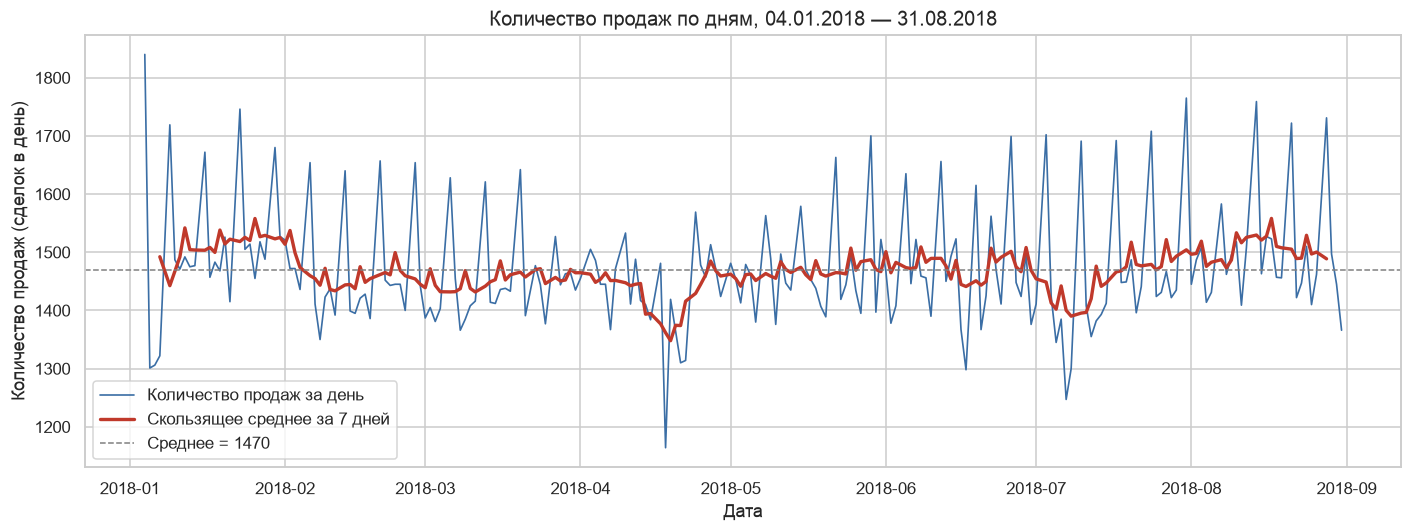

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(grouped_df["Дата"], grouped_df["Количество продаж"],
        linewidth=1.1, color="#3b6ea5", label="Количество продаж за день")
ax.plot(grouped_df["Дата"],
        grouped_df["Количество продаж"].rolling(7, center=True).mean(),
        linewidth=2.2, color="#c0392b", label="Скользящее среднее за 7 дней")
ax.axhline(grouped_df["Количество продаж"].mean(), linestyle="--", linewidth=1,
           color="grey", label=f"Среднее = {grouped_df['Количество продаж'].mean():.0f}")

ax.set_title("Количество продаж по дням, 04.01.2018 — 31.08.2018")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество продаж (сделок в день)")
ax.legend()
fig.tight_layout()
plt.show()

---
## Вопрос 7. Описать, что видно на графике (максимально подробно)

Сначала посчитаем цифры, на которые будет опираться описание: пропущенные календарные дни,
разрез по дням недели, разрез по месяцам, экстремумы и линейный тренд.

In [8]:
all_days = pd.date_range(grouped_df["Дата"].min(), grouped_df["Дата"].max(), freq="D")
missing_days = all_days.difference(pd.DatetimeIndex(grouped_df["Дата"]))

print("Календарных дней в периоде:", len(all_days))
print("Дней с продажами:", len(grouped_df))
print("Дней без единой продажи:", len(missing_days))
print()
print("Пропущенные дни по дням недели:")
print(pd.Series(missing_days).dt.day_name().value_counts())
print()
print("Пропущенные дни, которые НЕ понедельник:",
      [str(d.date()) for d in missing_days if d.weekday() != 0])

Календарных дней в периоде: 240
Дней с продажами: 205
Дней без единой продажи: 35

Пропущенные дни по дням недели:
Monday      34
Thursday     1
Name: count, dtype: int64

Пропущенные дни, которые НЕ понедельник: ['2018-03-22']


In [9]:
gd = grouped_df.copy()
gd["День недели"] = gd["Дата"].dt.day_name()
gd["Месяц"] = gd["Дата"].dt.month
gd["Номер дня недели"] = gd["Дата"].dt.weekday

by_weekday = (
    gd.groupby(["Номер дня недели", "День недели"])["Количество продаж"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(1)
)
print("Разрез по дням недели:")
print(by_weekday)
print()

by_month = (
    gd.groupby("Месяц")["Количество продаж"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(1)
)
print("Разрез по месяцам:")
print(by_month)

Разрез по дням недели:
                              count    mean  median   min   max
Номер дня недели День недели                                   
1                Tuesday         34  1643.3  1655.0  1481  1765
2                Wednesday       34  1437.0  1447.0  1164  1527
3                Thursday        34  1456.1  1446.0  1345  1840
4                Friday          35  1455.6  1467.0  1301  1562
5                Saturday        34  1418.1  1425.0  1247  1526
6                Sunday          34  1410.5  1411.5  1298  1508

Разрез по месяцам:
       count    mean  median   min   max
Месяц                                   
1         24  1514.3  1487.5  1301  1840
2         24  1465.7  1440.0  1350  1657
3         26  1448.2  1434.0  1366  1642
4         25  1431.3  1445.0  1164  1569
5         27  1469.6  1453.0  1376  1700
6         26  1470.8  1453.0  1298  1699
7         26  1462.3  1424.5  1247  1765
8         27  1498.4  1463.0  1366  1759


In [10]:
x = np.arange(len(grouped_df))
y = grouped_df["Количество продаж"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)

print("Топ-5 самых высоких дней:")
print(gd.nlargest(5, "Количество продаж")[["Дата", "День недели", "Количество продаж"]].to_string(index=False))
print()
print("Топ-5 самых низких дней:")
print(gd.nsmallest(5, "Количество продаж")[["Дата", "День недели", "Количество продаж"]].to_string(index=False))
print()
print(f"Линейный тренд: {slope:+.4f} продаж в день, то есть {slope * len(grouped_df):+.1f} продаж за весь период")
print(f"Корреляция количества продаж с номером дня: {np.corrcoef(x, y)[0, 1]:+.3f}")
print(f"Среднее по первым 30 дням: {y[:30].mean():.0f} | по последним 30 дням: {y[-30:].mean():.0f}")
print(f"Стандартное отклонение: {y.std(ddof=1):.1f} | коэффициент вариации: {y.std(ddof=1) / y.mean():.1%}")

Топ-5 самых высоких дней:
      Дата День недели  Количество продаж
2018-01-04    Thursday               1840
2018-07-31     Tuesday               1765
2018-08-14     Tuesday               1759
2018-01-23     Tuesday               1746
2018-08-28     Tuesday               1731

Топ-5 самых низких дней:
      Дата День недели  Количество продаж
2018-04-18   Wednesday               1164
2018-07-07    Saturday               1247
2018-06-17      Sunday               1298
2018-07-08      Sunday               1300
2018-01-05      Friday               1301

Линейный тренд: +0.0266 продаж в день, то есть +5.5 продаж за весь период
Корреляция количества продаж с номером дня: +0.015
Среднее по первым 30 дням: 1510 | по последним 30 дням: 1503
Стандартное отклонение: 102.3 | коэффициент вариации: 7.0%


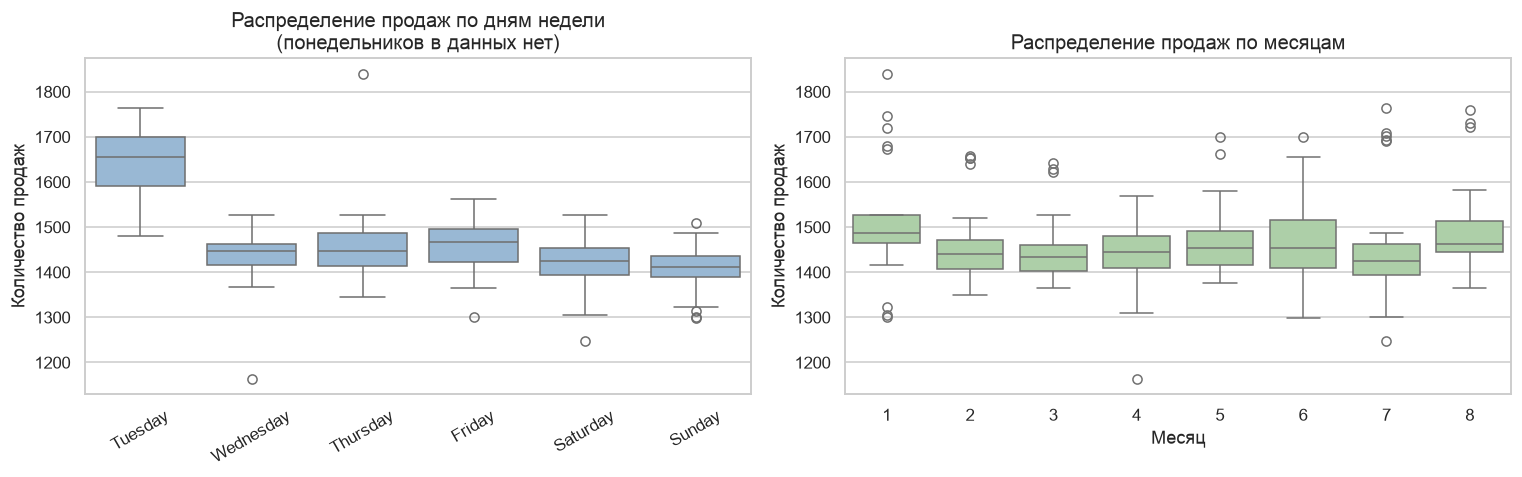

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = ["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=gd, x="День недели", y="Количество продаж", order=order,
            ax=axes[0], color="#8fb8de")
axes[0].set_title("Распределение продаж по дням недели\n(понедельников в данных нет)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=gd, x="Месяц", y="Количество продаж", ax=axes[1], color="#a8d5a2")
axes[1].set_title("Распределение продаж по месяцам")

fig.tight_layout()
plt.show()

### Описание графика

**1. Период и полнота ряда.** График покрывает 4 января — 31 августа 2018 года, это 240
календарных дней. Но точек на графике только **205**: **35 дней вообще отсутствуют** в данных.
Разбор пропусков даёт очень чёткую картину — **34 из 35 пропущенных дней это понедельники**
(все понедельники периода без исключения), а единственный «лишний» пропуск — **четверг
22 марта 2018**, то есть Наурыз, государственный праздник в Казахстане. Значит, это не дыры
в выгрузке и не потерянные данные: **компания просто не работает по понедельникам и в
праздник**. Поэтому линия на графике не рвётся, а идёт непрерывно — pandas соединяет соседние
рабочие дни, «перепрыгивая» выходной понедельник.

**2. Уровень и разброс.** Ряд держится в узком коридоре примерно **1160–1840 продаж в день**.
Среднее — **1470**, медиана — **1448**, стандартное отклонение — **102**, то есть коэффициент
вариации всего **7 %**. Это очень стабильный, «плоский» операционный ряд: типичный день
отклоняется от среднего меньше чем на сотню сделок. Никаких обвалов в разы или взрывного
роста на графике нет.

**3. Тренда практически нет.** Линейный тренд даёт наклон **+0.027 продажи в день**, то есть
за все восемь месяцев ряд «вырос» примерно на **+5 продаж** — на фоне уровня 1470 это ноль.
Корреляция с номером дня **+0.015**. Среднее по первым 30 дням — **1510**, по последним 30 дням —
**1503**. Красная линия скользящего среднего на графике колеблется около отметки 1470 и никуда
не уходит. Вывод: **бизнес работает на плато**, роста или спада за период не наблюдается.

**4. Главная закономерность — недельный цикл, а именно эффект вторника.** Разрез по дням недели
показывает то, что на дневном графике выглядит как «зубцы»:

| День недели | Среднее продаж |
|---|---|
| **Вторник** | **1643** |
| Четверг | 1456 |
| Пятница | 1456 |
| Среда | 1437 |
| Суббота | 1418 |
| Воскресенье | 1410 |

**Вторник стабильно выбивается вверх примерно на 190 продаж (+13 %)** относительно остальных
дней, а все прочие дни недели практически неотличимы друг от друга (1410–1456, разброс менее 4 %).
Объяснение прямо следует из пункта 1: понедельник — выходной, и спрос, накопившийся за понедельник,
выплёскивается в первый рабочий день недели. Именно этот эффект и создаёт регулярную «пилу»
на графике с периодом в неделю. Отдельно отмечу: воскресенье НЕ проваливается — то есть это
не розница с выходными, а скорее оптовые/дистрибуционные отгрузки с плавающим графиком.

**5. Сезонности по месяцам практически нет.** Средние по месяцам: январь 1514, февраль 1466,
март 1448, апрель 1431, май 1470, июнь 1471, июль 1462, август 1498. Размах между самым сильным
и самым слабым месяцем — **83 продажи, около 6 %**, и он полностью укладывается в обычный
дневной шум. Ни летнего затишья, ни предновогоднего/весеннего пика в данных не видно.
Слабый локальный минимум приходится на апрель, слабый максимум — на январь и август,
но статистически это несущественно.

**6. Отдельные выбросы вверх.** Самые высокие дни: **4 января 2018 — 1840 продаж** (это первый
день выгрузки, четверг после длинных новогодних каникул — накопленный за праздники спрос),
затем **31 июля — 1765**, **14 августа — 1759**, **23 января — 1746**, **28 августа — 1731**.
Показательно, что **все четыре последующих пика — вторники**, то есть это не аномалии,
а просто верхняя часть обычного «вторничного» распределения. По-настоящему аномален только
4 января: он на 3.6 стандартных отклонения выше среднего и стоит особняком.

**7. Отдельные выбросы вниз.** Самый низкий день — **18 апреля 2018, всего 1164 продажи**,
при том что типичная среда даёт 1437. Это провал на **19 %** ниже медианы своего дня недели
и минимум всего ряда — единственная настоящая аномалия вниз, которую стоит уточнить
у владельца данных (частичный простой, сбой учётной системы или неполная выгрузка за этот день).
Следующие по «слабости» дни — 7 июля (1247, суббота) и 17 июня (1298, воскресенье) — уже
укладываются в нормальный разброс выходных.

**Итог.** График показывает зрелый, стабильный процесс без тренда и без месячной сезонности,
с одним сильным и устойчивым паттерном — недельным циклом с пиком во вторник, обусловленным
нерабочим понедельником. Единственные точки, требующие внимания аналитика, — стартовый
всплеск 4 января и провал 18 апреля.

---
## Вопрос 8. Найти строку с максимальным выбросом по количеству продаж (выброс ищем у `df`)

**Как я определяю «выброс».** Ищем аномалию в исходной таблице `df` по столбцу `Количество`
(сколько штук ушло в одной сделке). Проверяем сразу три классических критерия, чтобы
ответ был обоснованным, а не просто «взяли максимум»:

1. **Правило IQR**: выброс — это значение выше `Q3 + 1.5 × IQR`.
2. **Z-оценка**: выброс — это значение, отстоящее от среднего больше чем на 3 стандартных отклонения.
3. **Максимум** — сама экстремальная строка, которую и просит задание.

In [12]:
qty = df["Количество"]
q1, q3 = qty.quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
z = (qty - qty.mean()) / qty.std()

print("Статистика столбца 'Количество':")
print(qty.describe().round(2))
print()
print(f"Q1 = {q1:.0f}, Q3 = {q3:.0f}, IQR = {iqr:.0f}")
print(f"Верхняя граница выбросов по IQR = Q3 + 1.5*IQR = {upper_bound:.1f} шт.")
print(f"Строк выше границы IQR: {(qty > upper_bound).sum()} из {len(df)} "
      f"({(qty > upper_bound).mean():.1%})")
print(f"Строк с z-оценкой выше 3: {(z > 3).sum()}")
print(f"Максимальная z-оценка в данных: {z.max():.1f}")

Статистика столбца 'Количество':
count    301355.00
mean          2.95
std           3.00
min           0.00
25%           1.00
50%           2.00
75%           4.00
max         200.00
Name: Количество, dtype: float64

Q1 = 1, Q3 = 4, IQR = 3
Верхняя граница выбросов по IQR = Q3 + 1.5*IQR = 8.5 шт.
Строк выше границы IQR: 13140 из 301355 (4.4%)
Строк с z-оценкой выше 3: 5322
Максимальная z-оценка в данных: 65.7


In [13]:
outlier_row = df.loc[[qty.idxmax()]]

print("СТРОКА С МАКСИМАЛЬНЫМ ВЫБРОСОМ ПО КОЛИЧЕСТВУ:")
print(outlier_row.to_string())
print()
print("Топ-5 самых крупных сделок для контекста:")
print(df.nlargest(5, "Количество").to_string())

СТРОКА С МАКСИМАЛЬНЫМ ВЫБРОСОМ ПО КОЛИЧЕСТВУ:
             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200

Топ-5 самых крупных сделок для контекста:
             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200
260398 2018-07-31      4  address_125    product_1         140
260399 2018-07-31      4  address_125    product_2         100
258867 2018-07-29      4  address_142    product_1          80
258868 2018-07-29      4  address_142    product_2          70


### Ответ

**Искомая строка — индекс 218822:**

| Дата | Склад | Контрагент | Номенклатура | Количество |
|---|---|---|---|---|
| **2018-06-28** | **1** | **address_208** | **product_0** | **200** |

**Почему это именно выброс.** Типичная сделка в данных — это 2 штуки (медиана), среднее 2.95,
75-й процентиль всего 4 штуки. Здесь **200 штук в одной строке** — это в 100 раз больше медианы.
Z-оценка этой строки — **65.7**, то есть она отстоит от среднего на 65 стандартных отклонений;
следующая по величине сделка — 140 штук (31 июля, склад 4), то есть максимум отрывается от
второго места ещё на 43 %.

**Про формальные критерии.** Граница IQR здесь равна `4 + 1.5 × 3 = 8.5` штуки, и выше неё
оказывается 13 140 строк (4.4 % данных) — это слишком мягкий порог для такого «сжатого»
распределения, где почти все значения лежат в диапазоне 0–5. Критерий z > 3 даёт 5 322 строки.
Поэтому оба порога годятся как контекст, но однозначный, «максимальный» выброс, который просит
задание — это именно строка на 200 штук.

**Что с ней делать.** Такая сделка — либо разовая крупная оптовая отгрузка контрагенту
`address_208`, либо ошибка ввода (лишний ноль: 20 вместо 200). Строку стоит подтвердить
у источника данных; при расчёте средних показателей её разумно исключать, иначе она будет
искажать среднее по товару `product_0`.

---
## Вопрос 9. Топовый товар по продажам по средам за июнь, июль, август у 3 склада

**Как я читаю условие.** Нужно последовательно наложить три фильтра на `df`:

1. `Склад == 3` — столбец целочисленный (проверено в вопросе 2), поэтому сравниваем с числом `3`, а не со строкой `"3"`;
2. день недели = **среда** → `df["Дата"].dt.weekday == 2` (нумерация с нуля: понедельник = 0);
3. месяц ∈ {6, 7, 8} — июнь, июль, август.

Затем группируем по `Номенклатура` и суммируем `Количество` — «топовый по продажам»
понимаю как **наибольшее суммарное число проданных штук**. Для контроля рядом привожу
рейтинг по числу сделок.

In [14]:
sub = df[
    (df["Склад"] == 3)
    & (df["Дата"].dt.weekday == 2)
    & (df["Дата"].dt.month.isin([6, 7, 8]))
]

print("Строк после фильтра:", len(sub))
print("Уникальных сред в выборке:", sub["Дата"].nunique())
print("Список этих сред:", [str(d.date()) for d in sorted(sub["Дата"].unique())])
print("Проверка фильтров — склады:", sub["Склад"].unique(),
      "| дни недели:", sub["Дата"].dt.day_name().unique(),
      "| месяцы:", sorted(sub["Дата"].dt.month.unique()))

Строк после фильтра: 4345
Уникальных сред в выборке: 13
Список этих сред: ['2018-06-06', '2018-06-13', '2018-06-20', '2018-06-27', '2018-07-04', '2018-07-11', '2018-07-18', '2018-07-25', '2018-08-01', '2018-08-08', '2018-08-15', '2018-08-22', '2018-08-29']
Проверка фильтров — склады: [3] | дни недели: <StringArray>
['Wednesday']
Length: 1, dtype: str | месяцы: [np.int32(6), np.int32(7), np.int32(8)]


In [15]:
top_by_qty = (
    sub.groupby("Номенклатура")["Количество"]
           .sum()
           .sort_values(ascending=False)
)

print("Рейтинг товаров по сумме проданных штук (топ-10):")
print(top_by_qty.head(10).to_string())
print()
print("Для контроля — рейтинг по числу сделок (топ-5):")
print(sub["Номенклатура"].value_counts().head(5).to_string())
print()
print(f"ОТВЕТ: топовый товар — {top_by_qty.index[0]}, "
      f"{int(top_by_qty.iloc[0])} шт. суммарно.")

Рейтинг товаров по сумме проданных штук (топ-10):
Номенклатура
product_1     2267
product_2     2060
product_0     1324
product_3      914
product_6      650
product_4      540
product_22     509
product_5      480
product_13     253
product_15     230

Для контроля — рейтинг по числу сделок (топ-5):
Номенклатура
product_1    521
product_2    519
product_0    485
product_3    483
product_4    377

ОТВЕТ: топовый товар — product_1, 2267 шт. суммарно.


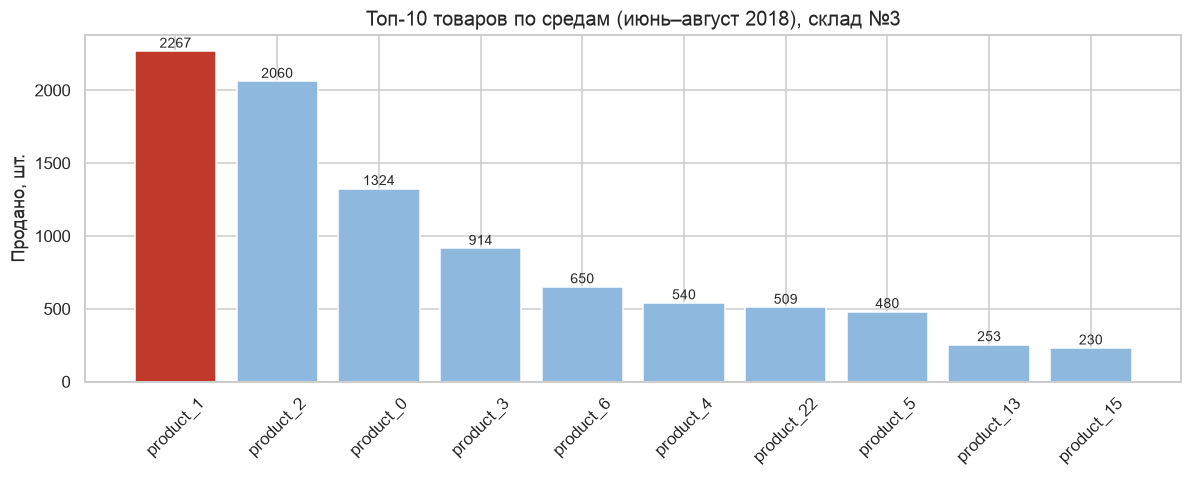

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
top10 = top_by_qty.head(10)
colors_ = ["#c0392b"] + ["#8fb8de"] * (len(top10) - 1)
ax.bar(top10.index, top10.values, color=colors_)
ax.set_title("Топ-10 товаров по средам (июнь–август 2018), склад №3")
ax.set_ylabel("Продано, шт.")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(top10.values):
    ax.text(i, v + 25, str(int(v)), ha="center", fontsize=9)
fig.tight_layout()
plt.show()

### Ответ

Фильтр `Склад == 3` + среда + июнь–август отобрал **4 345 строк** за **13 сред**
(6, 13, 20, 27 июня; 4, 11, 18, 25 июля; 1, 8, 15, 22, 29 августа) — фильтр точно сработал,
пустой выборки нет.

**Топовый товар — `product_1`, 2 267 штук** за эти 13 сред.

Ближайшие преследователи: `product_2` — 2 060 шт., `product_0` — 1 324 шт., `product_3` — 914 шт.
Отрыв лидера от второго места небольшой (около 10 %), а вот от третьего — уже почти двукратный.
Проверка по числу сделок даёт тот же порядок лидеров (`product_1` — 521 сделка, `product_2` — 519),
то есть результат устойчив и не создан одной крупной отгрузкой.

---
## Вопрос 10. Погода из rp5.ru: привести к «Дата + средняя температура за день», объединить с `grouped_df` и построить графики

Исходный файл выгружен с [rp5.ru / Архив погоды в Астане](https://rp5.ru/Архив_погоды_в_Астане)
за период 04.01.2018 – 31.08.2018 и лежит в `данные/rp5_астана_2018_исходные.csv`.

Что в нём неудобного и что с этим делать:

* первые **6 строк — служебный комментарий** с `#` (название станции, WMO_ID, лицензия) — пропускаем через `skiprows=6`;
* разделитель — **точка с запятой**, значения в кавычках;
* строка заголовка заканчивается лишней `;`, из-за чего pandas без `index_col=False` уводит первый столбец в индекс;
* время указано **по 3 часа** (8 замеров в сутки) в формате `31.08.2018 23:00`, то есть нужно разобрать
  дату вручную (`dayfirst`) и обрезать время до дня;
* нас интересуют только два столбца: время и `T` — температура воздуха на высоте 2 м.

Дальше группируем по дню и берём **среднее по `T`** — это и есть «средняя температура за день».

In [17]:
raw = pd.read_csv(
    "данные/rp5_астана_2018_исходные.csv",
    sep=";",
    skiprows=6,
    encoding="utf-8",
    index_col=False,
)

print("Размер исходной выгрузки rp5:", raw.shape)
print("Первые 6 столбцов:", raw.columns[:6].tolist())
raw.iloc[:5, :4]

Размер исходной выгрузки rp5: (1918, 29)
Первые 6 столбцов: ['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U']


,Местное время в Астане,T,Po,P
0,31.08.2018 23:00,8.2,736.6,768.3
1,31.08.2018 20:00,9.6,736.4,767.9
2,31.08.2018 17:00,11.3,735.2,766.4
3,31.08.2018 14:00,12.3,734.8,765.9
4,31.08.2018 11:00,13.2,733.9,764.8


In [18]:
raw = raw.rename(columns={raw.columns[0]: "Местное время"})
raw["Местное время"] = pd.to_datetime(raw["Местное время"], format="%d.%m.%Y %H:%M")
raw["Дата"] = raw["Местное время"].dt.normalize()
raw["T"] = pd.to_numeric(raw["T"], errors="coerce")

print("Замеров всего:", len(raw))
print("Замеров в сутки:")
print(raw.groupby("Дата").size().value_counts().to_string())
print("Пропусков температуры:", raw["T"].isna().sum())

weather = raw.groupby("Дата", as_index=False)["T"].mean()
weather["T"] = weather["T"].round(1)

print()
print("Готовая таблица погоды:", weather.shape)
weather.head(10)

Замеров всего: 1918
Замеров в сутки:
8    239
6      1
Пропусков температуры: 0

Готовая таблица погоды: (240, 2)


,Дата,T
0,2018-01-04,-14.1
1,2018-01-05,-16.9
2,2018-01-06,-13.3
3,2018-01-07,-12.8
4,2018-01-08,-15.4
5,2018-01-09,-6.2
6,2018-01-10,-1.5
7,2018-01-11,-9.5
8,2018-01-12,-15.0
9,2018-01-13,-24.0


In [19]:
print("Период погоды:", weather["Дата"].min().date(), "—", weather["Дата"].max().date(),
      f"({len(weather)} дней)")
print("Период продаж:", grouped_df["Дата"].min().date(), "—", grouped_df["Дата"].max().date(),
      f"({len(grouped_df)} дней)")

merged_df = grouped_df.merge(weather, on="Дата", how="left")

print()
print("Строк после объединения:", len(merged_df))
print("Дней, для которых нашлась температура:", merged_df["T"].notna().sum())
print("Дней без температуры:", merged_df["T"].isna().sum())
print("Дней погоды, не попавших в итог (нет продаж — понедельники и Наурыз):",
      len(weather) - len(merged_df))
print()
merged_df.head(10)

Период погоды: 2018-01-04 — 2018-08-31 (240 дней)
Период продаж: 2018-01-04 — 2018-08-31 (205 дней)

Строк после объединения: 205
Дней, для которых нашлась температура: 205
Дней без температуры: 0
Дней погоды, не попавших в итог (нет продаж — понедельники и Наурыз): 35



,Дата,Количество продаж,Сумма штук,T
0,2018-01-04,1840,3734,-14.1
1,2018-01-05,1301,3643,-16.9
2,2018-01-06,1306,3193,-13.3
3,2018-01-07,1322,3298,-12.8
4,2018-01-09,1719,4055,-6.2
5,2018-01-10,1487,3653,-1.5
6,2018-01-11,1471,3176,-9.5
7,2018-01-12,1492,3092,-15.0
8,2018-01-13,1475,3294,-24.0
9,2018-01-14,1477,3228,-25.0


**Про пересечение периодов.** Оба ряда покрывают ровно один и тот же интервал 04.01.2018 – 31.08.2018.
Погода есть за **все 240 календарных дней**, продажи — только за **205 рабочих дней**. Соединяем
левым `merge` по `Дата` от `grouped_df`, поэтому в итоге **205 строк, и температура нашлась для всех
205 из них — ни одного пропуска**. 35 «лишних» дней погоды (34 понедельника + 22 марта) в объединение
не попадают, так как в эти дни продаж не было.

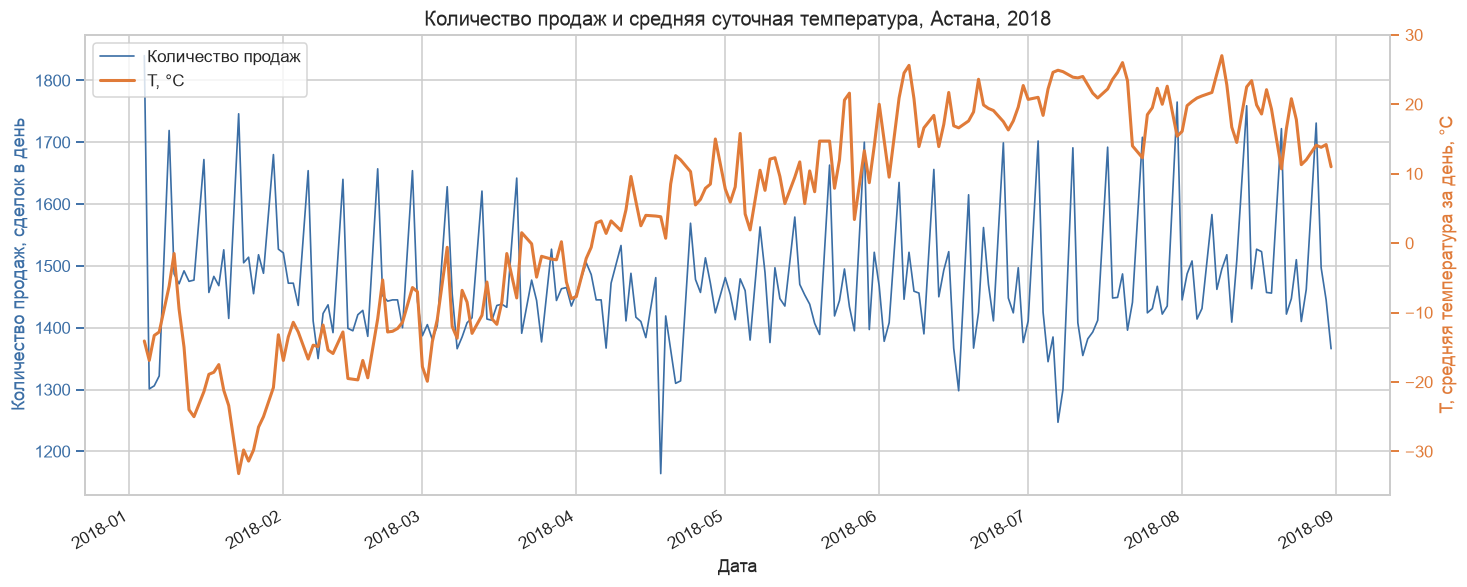

In [20]:
fig, ax = plt.subplots(figsize=(13.5, 5.5))

merged_df.plot(x="Дата", y="Количество продаж", ax=ax,
               color="#3b6ea5", linewidth=1.1, legend=False)
ax2 = ax.twinx()
merged_df.plot(x="Дата", y="T", ax=ax2,
               color="#e07b39", linewidth=2, legend=False)

ax.set_ylabel("Количество продаж, сделок в день", color="#3b6ea5")
ax2.set_ylabel("T, средняя температура за день, °C", color="#e07b39")
ax.tick_params(axis="y", colors="#3b6ea5")
ax2.tick_params(axis="y", colors="#e07b39")
ax2.grid(False)
ax.set_xlabel("Дата")
ax.set_title("Количество продаж и средняя суточная температура, Астана, 2018")

lines_ = ax.get_lines() + ax2.get_lines()
ax.legend(lines_, ["Количество продаж", "T, °C"], loc="upper left")

fig.tight_layout()
plt.show()

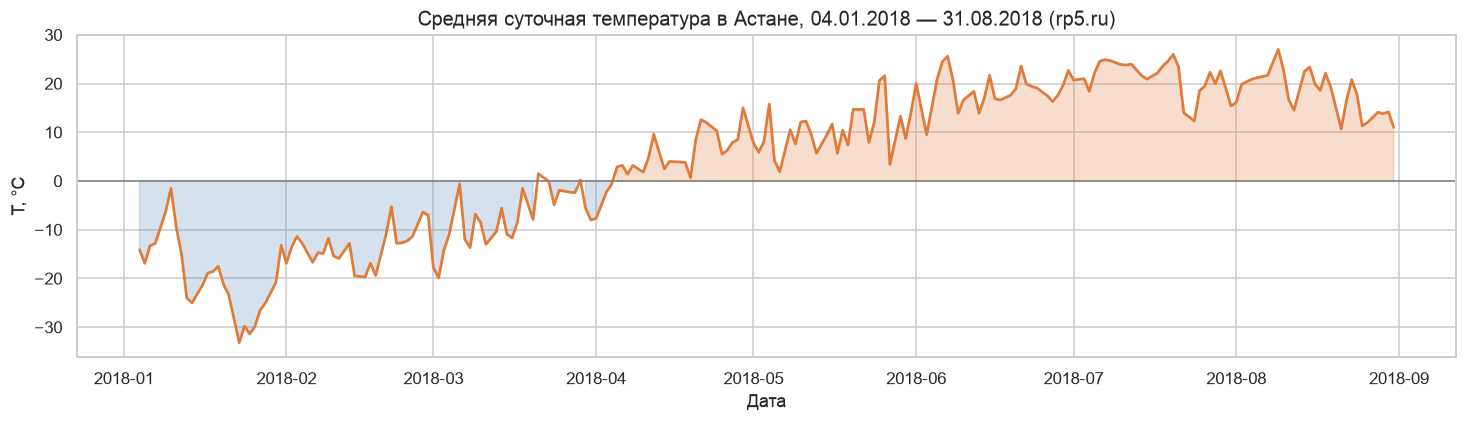

In [21]:
fig, ax = plt.subplots(figsize=(13.5, 4))

ax.plot(merged_df["Дата"], merged_df["T"], color="#e07b39", linewidth=1.8)
ax.fill_between(merged_df["Дата"], 0, merged_df["T"],
                where=merged_df["T"] >= 0, color="#e07b39", alpha=0.25)
ax.fill_between(merged_df["Дата"], merged_df["T"], 0,
                where=merged_df["T"] < 0, color="#5b8db8", alpha=0.25)
ax.axhline(0, color="grey", linewidth=1)

ax.set_title("Средняя суточная температура в Астане, 04.01.2018 — 31.08.2018 (rp5.ru)")
ax.set_xlabel("Дата")
ax.set_ylabel("T, °C")
fig.tight_layout()
plt.show()

In [22]:
pearson = merged_df["Количество продаж"].corr(merged_df["T"])
spearman = merged_df["Количество продаж"].corr(merged_df["T"], method="spearman")

print(f"Корреляция 'Количество продаж' и 'T': Пирсон r = {pearson:+.3f}, Спирмен rho = {spearman:+.3f}")
print()
print("Средняя температура по месяцам, °C:")
print(merged_df.assign(Month=merged_df["Дата"].dt.month)
               .groupby("Month")["T"].mean().round(1).to_string())
print()
print(f"Минимум температуры: {merged_df['T'].min():.1f} °C — "
      f"{merged_df.loc[merged_df['T'].idxmin(), 'Дата'].date()}")
print(f"Максимум температуры: {merged_df['T'].max():.1f} °C — "
      f"{merged_df.loc[merged_df['T'].idxmax(), 'Дата'].date()}")

Корреляция 'Количество продаж' и 'T': Пирсон r = -0.024, Спирмен rho = +0.002

Средняя температура по месяцам, °C:
Month
1   -19.5
2   -13.8
3    -7.6
4     5.0
5    10.3
6    18.6
7    21.5
8    18.3

Минимум температуры: -33.2 °C — 2018-01-23
Максимум температуры: 27.0 °C — 2018-08-09


### Что показывают графики

**Температура** ведёт себя ровно так, как и должна в резко континентальном климате Астаны:
монотонный сезонный подъём. По полной таблице погоды (240 дней) минимум — **−34.7 °C (22 января)**,
максимум — **+27.1 °C (9 июля)**, размах почти **62 градуса**; оба этих дня — понедельники, поэтому
в объединённую таблицу они не попали, и по 205 рабочим дням экстремумы чуть мягче:
**−33.2 °C (23 января)** и **+27.0 °C (9 августа)**. По месяцам: январь −19.5, февраль −13.8, март −7.6, апрель +5.0, май +10.3,
июнь +18.6, июль +21.5, август +18.3. Переход через ноль происходит в конце марта — начале апреля.

**Продажи на этот подъём никак не реагируют.** На совмещённом графике оранжевая кривая
температуры уходит с −30 на +25, а синяя кривая продаж как колебалась в коридоре 1160–1840,
так и продолжает колебаться в том же коридоре — ни сдвига уровня, ни изменения амплитуды.
Формально: **коэффициент Пирсона −0.024, Спирмена +0.002** — это статистический ноль
(на 205 наблюдениях такая корреляция неотличима от случайной).

**Вывод.** Среднесуточная температура **не объясняет** динамику количества продаж в этих данных.
Спрос здесь определяется не погодой, а рабочим календарём: главный и практически единственный
драйвер колебаний — недельный цикл с нерабочим понедельником и пиком во вторник (вопрос 7).
Для прогнозной модели это значит, что признак «температура» брать бесполезно, а вот
«день недели» — обязателен.

---
## Итоговые ответы блока

| № | Вопрос | Ответ |
|---|---|---|
| 1 | Прочитать `data.csv` в `df`, показать первые строки | 301 355 строк × 5 столбцов, период 04.01.2018–31.08.2018 |
| 2 | Проверить формат столбцов | Пропусков нет; `Склад` и `Количество` — `int64`; `Дата` прочиталась как строка и требует конвертации |
| 3 | Перевести «Дата» в правильный формат | `pd.to_datetime` → `datetime64[ns]`, 205 уникальных дат |
| 4 | Сгруппировать по дате, посчитать продажи | `grouped_df`: 205 строк, среднее 1470 продаж в день |
| 5 | Первые строки `grouped_df` | Выведены; минимум 1164, максимум 1840 |
| 6 | График продаж | Построен, со скользящим средним за 7 дней |
| 7 | Описание графика | Тренда нет (+5 продаж за 8 месяцев), сезонности нет; 34 понедельника и Наурыз — нерабочие; пик по вторникам (+13 %); аномалии 04.01 (1840) и 18.04 (1164) |
| 8 | Строка с максимальным выбросом | 2018-06-28, склад 1, `address_208`, `product_0`, **200 шт.**, z = 65.7 |
| 9 | Топовый товар по средам июнь–август, склад 3 | **`product_1` — 2 267 шт.** (4 345 строк, 13 сред) |
| 10 | Погода + объединение + графики | 205 из 205 дней склеились; корреляция продаж и температуры ≈ 0 (r = −0.024) |